In [65]:
import uproot
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy.stats import wasserstein_distance
import time
import io

# ── paths ─────────────────────────────────────────────────────────
ROOT_PATH  = Path("E:/Python/MSc_Project_Upgrade/generation/root_files/")
PLOT_PATH  = Path("E:/Python/MSc_Project_Upgrade/results_analysis/kinematics/300GeV_test_data_results")
PLOT_PATH.mkdir(parents=True, exist_ok=True)

PT_MIN, PT_MAX = 15.0, 150.0
ENERGY_TAG     = "300 GeV"
    
FILES = {
    "tau": "ee_tau_300GeV_50k_test.root",
    "jj":  "ee_jj_300GeV_50k_test.root",
    "bb":  "ee_bb_300GeV_50k_test.root",
}
COLORS = {"tau": "tab:blue", "jj": "tab:orange", "bb": "tab:green"}

# ── text report buffer ────────────────────────────────────────────
report_lines = []

def rlog(*args):
    """Print and also append to report buffer."""
    line = " ".join(str(a) for a in args)
    print(line)
    report_lines.append(line)

def rsep(char="=", n=60):
    rlog(char * n)

KINEMATICS ANALYSIS REPORT — 300 GeV
pT window : 15.0–150.0 GeV
SECTION 1 — Basic file checks

Event counts:
   tau :  50,000 events
    jj :  50,000 events
    bb :  50,000 events

Jets per event:
   tau : mean=1.24  0-jet events=7,552  (15.1%)
    jj : mean=2.42  0-jet events=373  (0.7%)
    bb : mean=2.42  0-jet events=121  (0.2%)


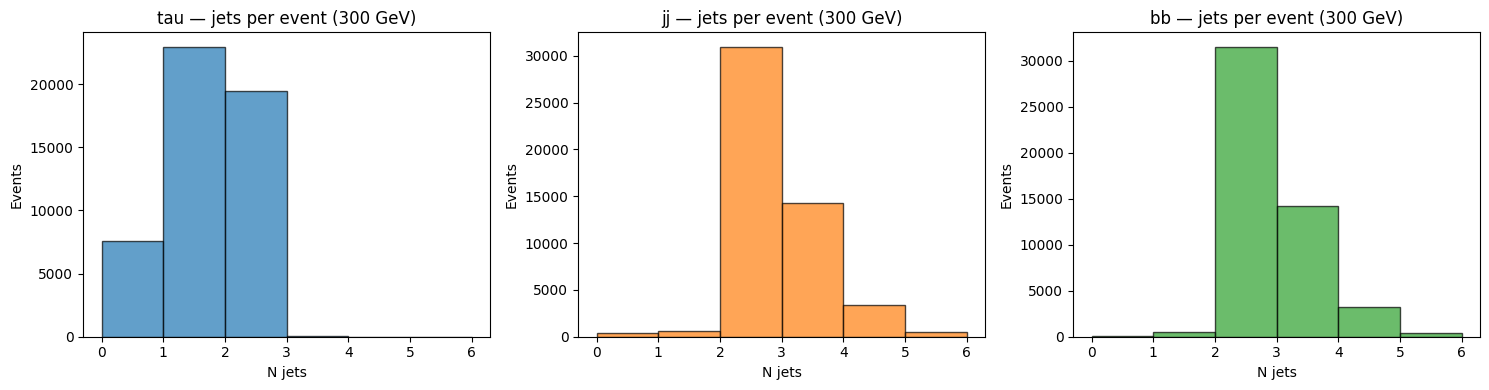


Jet pT overview (all jets, no cut):
   tau : total jets= 62,027  mean pT=72.8 GeV
    jj : total jets=121,099  mean pT=82.2 GeV
    bb : total jets=121,209  mean pT=78.8 GeV


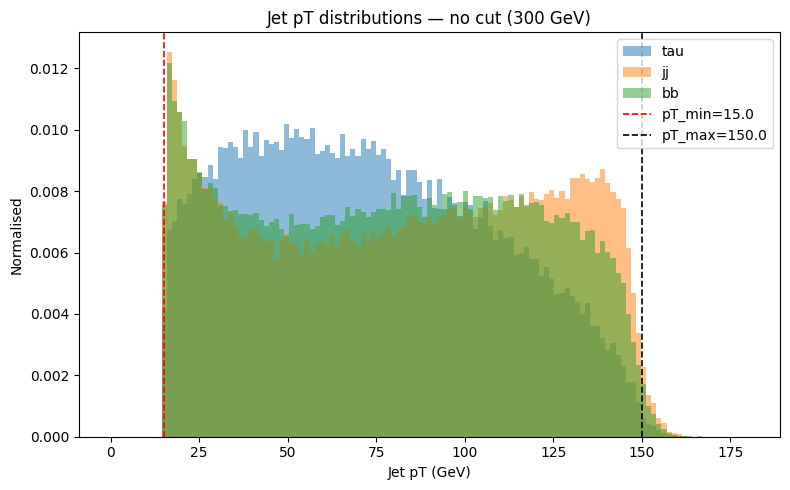


TauTag and BTag rates (all jets):
   tau : TauTag=39.8%  BTag=1.3%
    jj : TauTag=0.2%  BTag=6.7%
    bb : TauTag=1.5%  BTag=57.9%


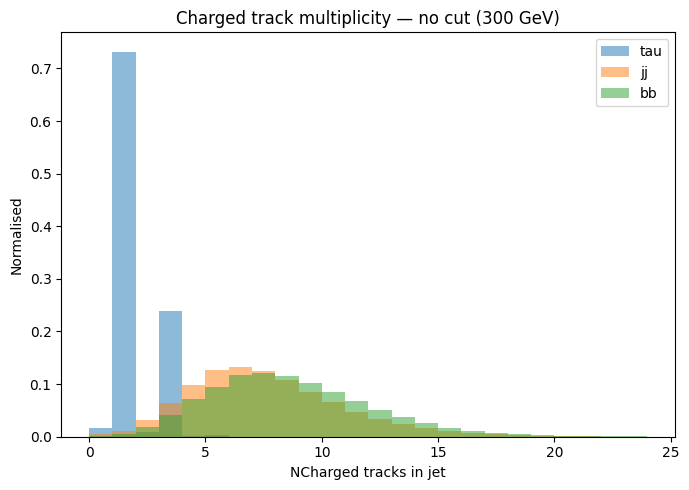

In [66]:
# ══════════════════════════════════════════════════════════════════
# SECTION 1 — Basic file checks
# ══════════════════════════════════════════════════════════════════
rsep()
rlog(f"KINEMATICS ANALYSIS REPORT — {ENERGY_TAG}")
rlog(f"pT window : {PT_MIN}–{PT_MAX} GeV")
rsep()

rsep()
rlog("SECTION 1 — Basic file checks")
rsep()

trees = {}
for name, fname in FILES.items():
    trees[name] = uproot.open(ROOT_PATH / fname)["Delphes;1"]

# event counts
rlog("\nEvent counts:")
for name, tree in trees.items():
    n = tree["Event_size"].array(library="np")
    rlog(f"  {name:>4s} : {len(n):>7,} events")

# ── jets per event ────────────────────────────────────────────────
rlog("\nJets per event:")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, tree) in zip(axes, trees.items()):
    jet_size = tree["Jet_size"].array(library="np")
    ax.hist(jet_size, bins=range(0, 7), edgecolor="black", alpha=0.7,
            color=COLORS[name])
    ax.set_title(f"{name} — jets per event ({ENERGY_TAG})")
    ax.set_xlabel("N jets")
    ax.set_ylabel("Events")
    rlog(f"  {name:>4s} : mean={jet_size.mean():.2f}  "
         f"0-jet events={(jet_size == 0).sum():,}  "
         f"({100*(jet_size==0).mean():.1f}%)")
plt.tight_layout()
plt.savefig(PLOT_PATH / "00_jets_per_event.png", dpi=150)
plt.show()

# ── jet pT overview ───────────────────────────────────────────────
rlog("\nJet pT overview (all jets, no cut):")
fig, ax = plt.subplots(figsize=(8, 5))
for name, tree in trees.items():
    pt_flat = np.concatenate(tree["Jet/Jet.PT"].array(library="np"))
    ax.hist(pt_flat, bins=125, range=(0, 180), alpha=0.5,
            label=name, color=COLORS[name], density=True)
    rlog(f"  {name:>4s} : total jets={len(pt_flat):>7,}  "
         f"mean pT={pt_flat.mean():.1f} GeV")
ax.axvline(PT_MIN, color="red",   ls="--", lw=1.2, label=f"pT_min={PT_MIN}")
ax.axvline(PT_MAX, color="black", ls="--", lw=1.2, label=f"pT_max={PT_MAX}")
ax.set_xlabel("Jet pT (GeV)")
ax.set_ylabel("Normalised")
ax.set_title(f"Jet pT distributions — no cut ({ENERGY_TAG})")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH / "00_pt_overview.png", dpi=150)
plt.show()

# ── TauTag and BTag rates ─────────────────────────────────────────
rlog("\nTauTag and BTag rates (all jets):")
for name, tree in trees.items():
    tt = np.concatenate(tree["Jet/Jet.TauTag"].array(library="np"))
    bt = np.concatenate(tree["Jet/Jet.BTag"].array(library="np"))
    rlog(f"  {name:>4s} : TauTag={tt.mean()*100:.1f}%  "
         f"BTag={bt.mean()*100:.1f}%")

# ── NCharged overview ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, tree in trees.items():
    nch = np.concatenate(tree["Jet/Jet.NCharged"].array(library="np"))
    ax.hist(nch, bins=range(0, 25), alpha=0.5,
            label=name, color=COLORS[name], density=True)
ax.set_xlabel("NCharged tracks in jet")
ax.set_ylabel("Normalised")
ax.set_title(f"Charged track multiplicity — no cut ({ENERGY_TAG})")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH / "00_ncharged_overview.png", dpi=150)
plt.show()

SECTION 2 — pT window study

Jet counts at different pT cuts:

  tau:
    15–145 GeV :  61,379  (99.0%)
    15–150 GeV :  61,871  (99.7%)
    15–155 GeV :  61,993  (99.9%)
    15–175 GeV :  62,027  (100.0%)
    50–140 GeV :  41,358  (66.7%)
    50–1500 GeV :  42,848  (69.1%)

  jj:
    15–145 GeV : 117,120  (96.7%)
    15–150 GeV : 120,093  (99.2%)
    15–155 GeV : 120,911  (99.8%)
    15–175 GeV : 121,099  (100.0%)
    50–140 GeV :  78,509  (64.8%)
    50–1500 GeV :  87,254  (72.1%)

  bb:
    15–145 GeV : 118,530  (97.8%)
    15–150 GeV : 120,502  (99.4%)
    15–155 GeV : 121,107  (99.9%)
    15–175 GeV : 121,209  (100.0%)
    50–140 GeV :  80,094  (66.1%)
    50–1500 GeV :  86,123  (71.1%)


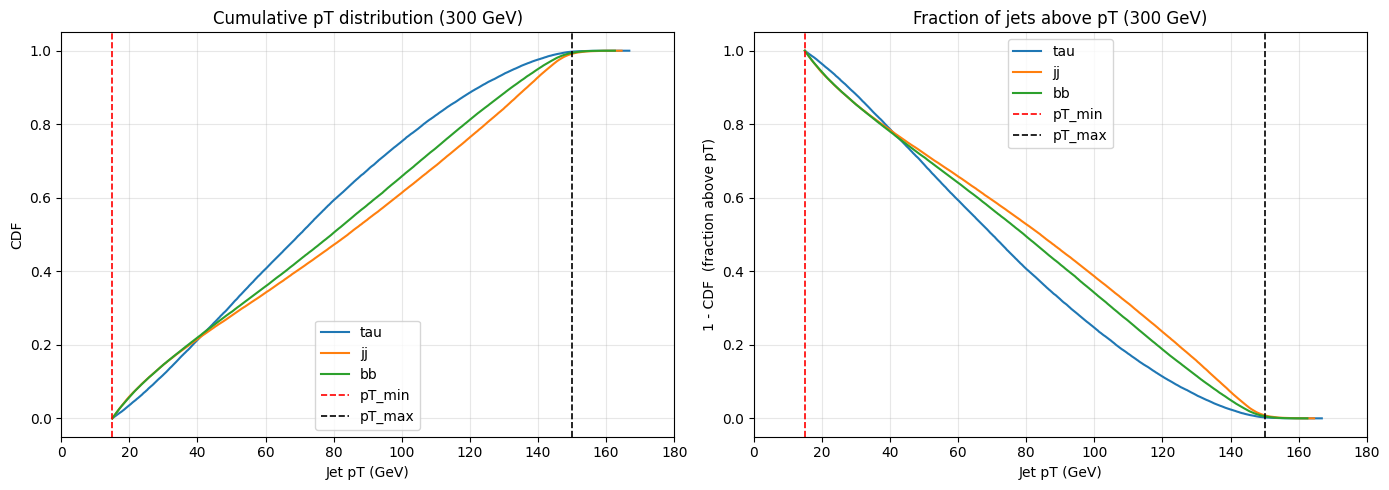

In [67]:
# ══════════════════════════════════════════════════════════════════
# SECTION 2 — pT window study
# ══════════════════════════════════════════════════════════════════
rsep()
rlog("SECTION 2 — pT window study")
rsep()

rlog(f"\nJet counts at different pT cuts:")
for name, tree in trees.items():
    pt = np.concatenate(tree["Jet/Jet.PT"].array(library="np"))
    rlog(f"\n  {name}:")
    for lo, hi in [(15, 145), (15, 150), (15, 155), (15, 175), (50, 140), (50, 1500)]:
        n = ((pt >= lo) & (pt <= hi)).sum()
        rlog(f"    {lo}–{hi} GeV : {n:>7,}  ({100*n/len(pt):.1f}%)")

# ── cumulative pT distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, tree in trees.items():
    pt = np.concatenate(tree["Jet/Jet.PT"].array(library="np"))
    pt_sorted = np.sort(pt)
    cdf = np.arange(1, len(pt_sorted)+1) / len(pt_sorted)
    axes[0].plot(pt_sorted, cdf, label=name, color=COLORS[name])
    axes[1].plot(pt_sorted, 1 - cdf, label=name, color=COLORS[name])

for ax in axes:
    ax.axvline(PT_MIN, color="red",   ls="--", lw=1.2, label=f"pT_min")
    ax.axvline(PT_MAX, color="black", ls="--", lw=1.2, label=f"pT_max")
    ax.set_xlabel("Jet pT (GeV)")
    ax.set_xlim(0, 180)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("CDF")
axes[0].set_title(f"Cumulative pT distribution ({ENERGY_TAG})")
axes[1].set_ylabel("1 - CDF  (fraction above pT)")
axes[1].set_title(f"Fraction of jets above pT ({ENERGY_TAG})")
plt.tight_layout()
plt.savefig(PLOT_PATH / "00b_pt_cdf.png", dpi=150)
plt.show()

In [68]:
# ══════════════════════════════════════════════════════════════════
# SECTION 3 — Constituent check with pT window
# ══════════════════════════════════════════════════════════════════
rsep()
rlog(f"SECTION 3 — Constituent check (pT {PT_MIN}–{PT_MAX} GeV)")
rsep()

for name, fname in FILES.items():
    t0   = time.time()
    tree = uproot.open(ROOT_PATH / fname)["Delphes;1"]

    jet_pt  = tree["Jet/Jet.PT"].array(library="ak")
    jet_eta = tree["Jet/Jet.Eta"].array(library="ak")
    jet_phi = tree["Jet/Jet.Phi"].array(library="ak")
    trk_eta = tree["EFlowTrack/EFlowTrack.Eta"].array(library="ak")
    trk_phi = tree["EFlowTrack/EFlowTrack.Phi"].array(library="ak")
    trk_pt  = tree["EFlowTrack/EFlowTrack.PT"].array(library="ak")
    pho_eta = tree["EFlowPhoton/EFlowPhoton.Eta"].array(library="ak")
    pho_phi = tree["EFlowPhoton/EFlowPhoton.Phi"].array(library="ak")
    pho_et  = tree["EFlowPhoton/EFlowPhoton.ET"].array(library="ak")
    neu_eta = tree["EFlowNeutralHadron/EFlowNeutralHadron.Eta"].array(library="ak")
    neu_phi = tree["EFlowNeutralHadron/EFlowNeutralHadron.Phi"].array(library="ak")
    neu_et  = tree["EFlowNeutralHadron/EFlowNeutralHadron.ET"].array(library="ak")

    total_jets = jets_in_window = jets_nonzero = 0

    for ev in tqdm(range(len(jet_pt)), desc=f"  {name}", leave=True):
        for j in range(len(jet_pt[ev])):
            total_jets += 1
            jpt = float(jet_pt[ev][j])
            if jpt < PT_MIN or jpt > PT_MAX:
                continue
            jets_in_window += 1
            j_eta = float(jet_eta[ev][j])
            j_phi = float(jet_phi[ev][j])

            def cone(p_eta, p_phi, p_pt):
                p_eta = np.array(p_eta); p_phi = np.array(p_phi); p_pt = np.array(p_pt)
                dphi  = (p_phi - j_phi + np.pi) % (2*np.pi) - np.pi
                dR    = np.sqrt((p_eta - j_eta)**2 + dphi**2)
                return p_pt[dR < 0.4]

            t = cone(trk_eta[ev], trk_phi[ev], trk_pt[ev])
            p = cone(pho_eta[ev], pho_phi[ev], pho_et[ev])
            n = cone(neu_eta[ev], neu_phi[ev], neu_et[ev])
            if (t.sum() + p.sum() + n.sum()) > 0:
                jets_nonzero += 1

    elapsed = time.time() - t0
    rlog(f"\n  ── {name} ───────────────────────────────")
    rlog(f"    Total jets            : {total_jets:>7,}")
    rlog(f"    After pT window       : {jets_in_window:>7,}")
    rlog(f"    Non-zero constituents : {jets_nonzero:>7,}")
    rlog(f"    Zero constituent jets : {jets_in_window - jets_nonzero:>7,}")
    rlog(f"    Time: {elapsed:.1f}s")

SECTION 3 — Constituent check (pT 15.0–150.0 GeV)


  tau: 100%|██████████| 50000/50000 [03:13<00:00, 257.80it/s]



  ── tau ───────────────────────────────
    Total jets            :  62,027
    After pT window       :  61,871
    Non-zero constituents :  61,871
    Zero constituent jets :       0
    Time: 194.5s


  jj: 100%|██████████| 50000/50000 [06:51<00:00, 121.59it/s]



  ── jj ───────────────────────────────
    Total jets            : 121,099
    After pT window       : 120,093
    Non-zero constituents : 120,093
    Zero constituent jets :       0
    Time: 413.9s


  bb: 100%|██████████| 50000/50000 [05:42<00:00, 146.05it/s]


  ── bb ───────────────────────────────
    Total jets            : 121,209
    After pT window       : 120,502
    Non-zero constituents : 120,502
    Zero constituent jets :       0
    Time: 344.6s


SECTION 4 — Full kinematics (pT 15.0–150.0 GeV)

Loading jets...


C:\Users\User\AppData\Local\Temp\ipykernel_17868\256414004.py:43: RuntimeWarning: invalid value encountered in divide
  result["tau2"] / result["tau1"], 0)
C:\Users\User\AppData\Local\Temp\ipykernel_17868\256414004.py:45: RuntimeWarning: invalid value encountered in divide
  result["tau3"] / result["tau2"], 0)


  Loaded ee_tau_300GeV_50k_test.root — 61,871 jets  (33.4s)
  Loaded ee_jj_300GeV_50k_test.root — 120,093 jets  (32.4s)
  Loaded ee_bb_300GeV_50k_test.root — 120,502 jets  (34.7s)

Substructure branch check:
   tau : PTD nonzero=0  MSDR nonzero=0  Tau1 nonzero=53,055  Tau1 mean=0.0275
    jj : PTD nonzero=0  MSDR nonzero=0  Tau1 nonzero=120,024  Tau1 mean=0.2008
    bb : PTD nonzero=0  MSDR nonzero=0  Tau1 nonzero=120,488  Tau1 mean=0.2306


Plotting kinematics:   0%|          | 0/14 [00:00<?, ?it/s]

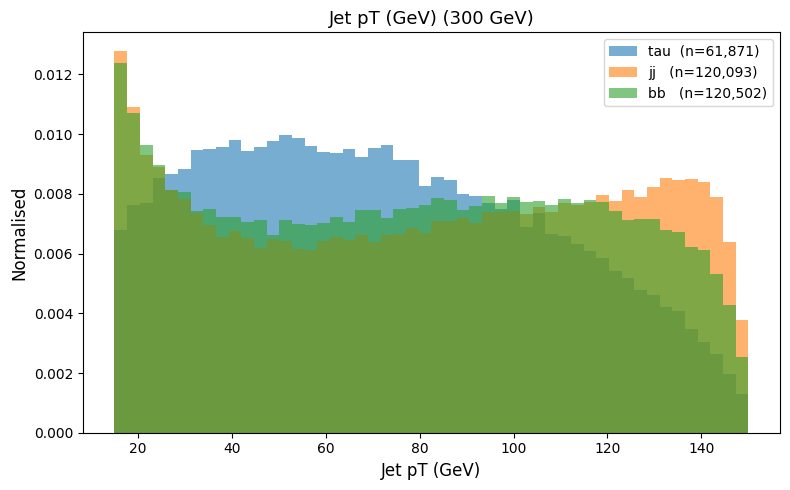

Plotting kinematics:   7%|▋         | 1/14 [00:01<00:24,  1.87s/it]

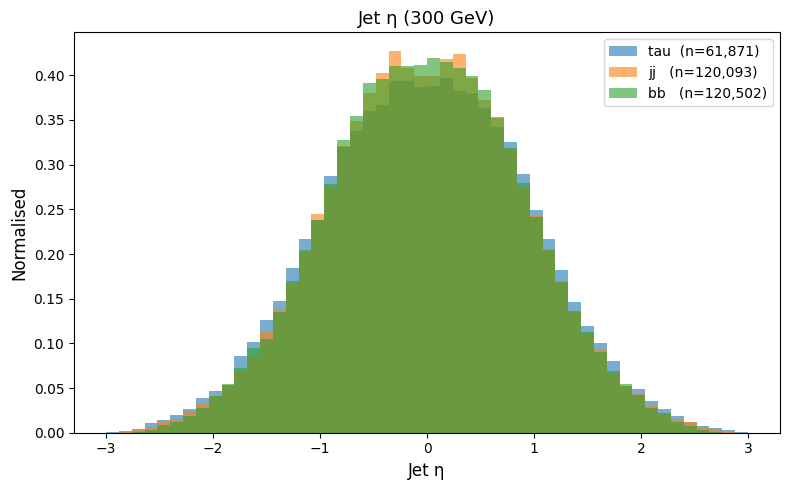

Plotting kinematics:  14%|█▍        | 2/14 [00:03<00:23,  1.93s/it]

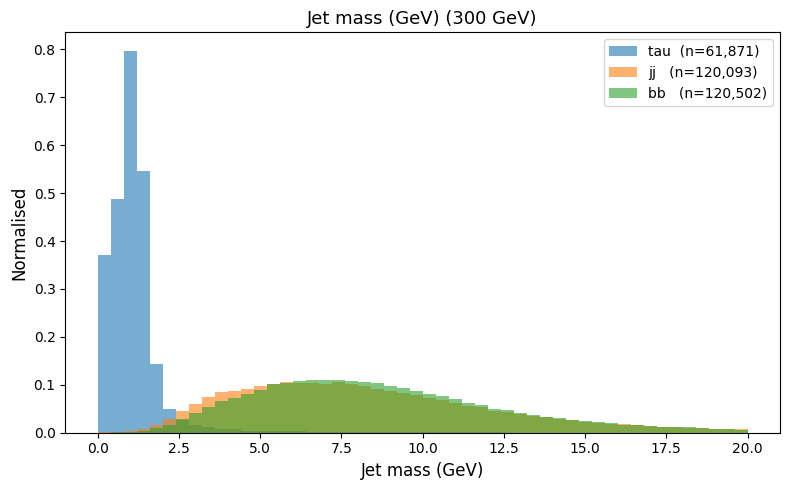

Plotting kinematics:  21%|██▏       | 3/14 [00:05<00:21,  1.93s/it]

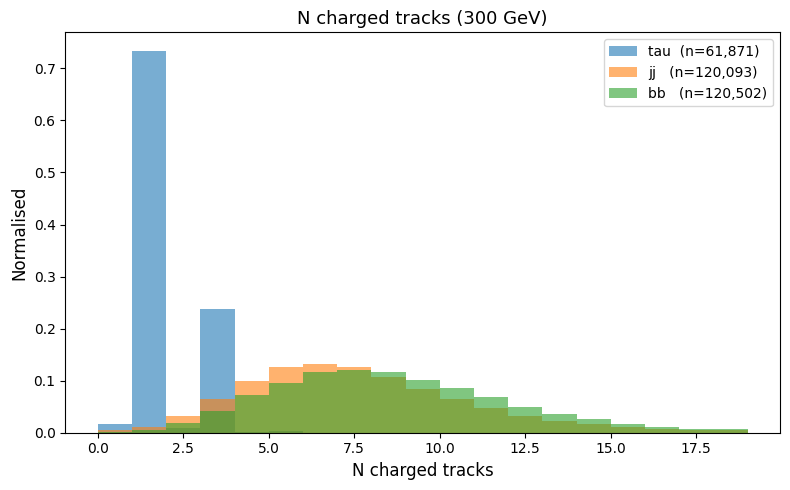

Plotting kinematics:  29%|██▊       | 4/14 [00:07<00:17,  1.77s/it]

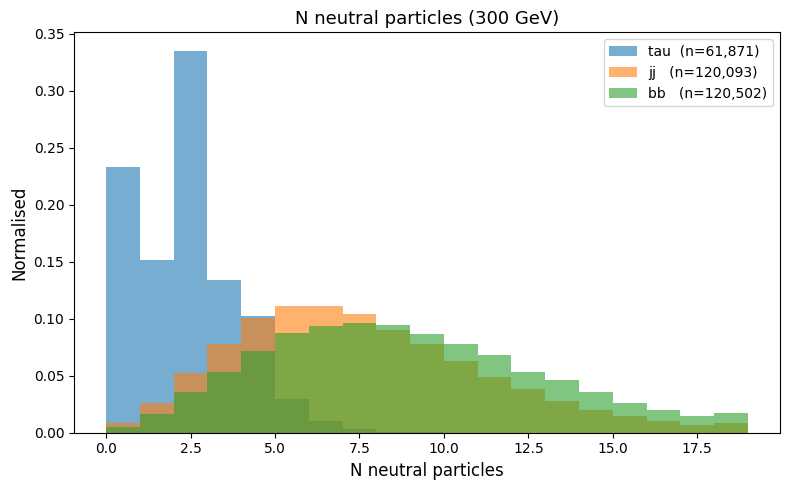

Plotting kinematics:  36%|███▌      | 5/14 [00:08<00:14,  1.66s/it]

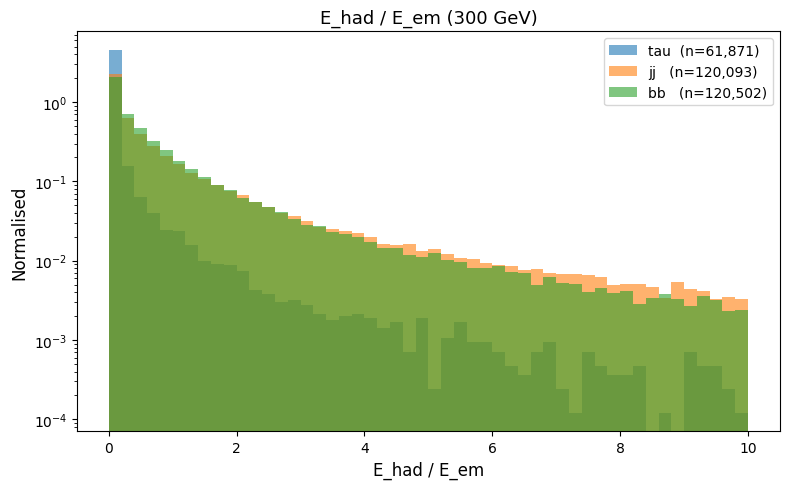

Plotting kinematics:  43%|████▎     | 6/14 [00:11<00:16,  2.06s/it]

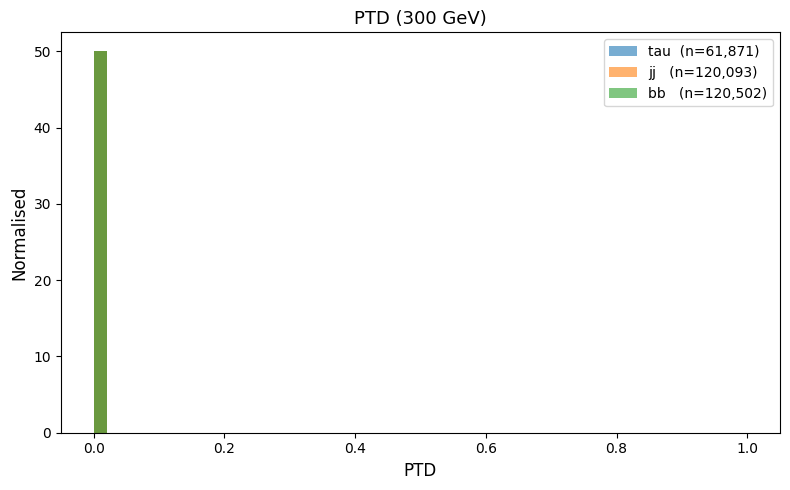

Plotting kinematics:  50%|█████     | 7/14 [00:13<00:14,  2.08s/it]

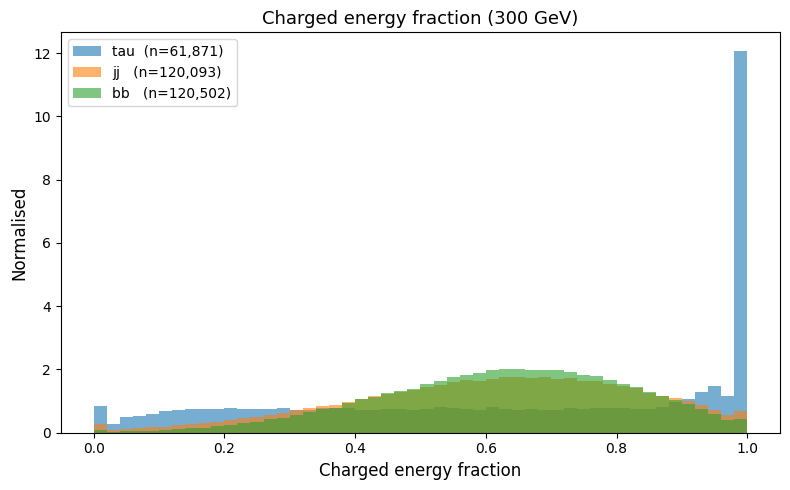

Plotting kinematics:  57%|█████▋    | 8/14 [00:15<00:11,  1.97s/it]

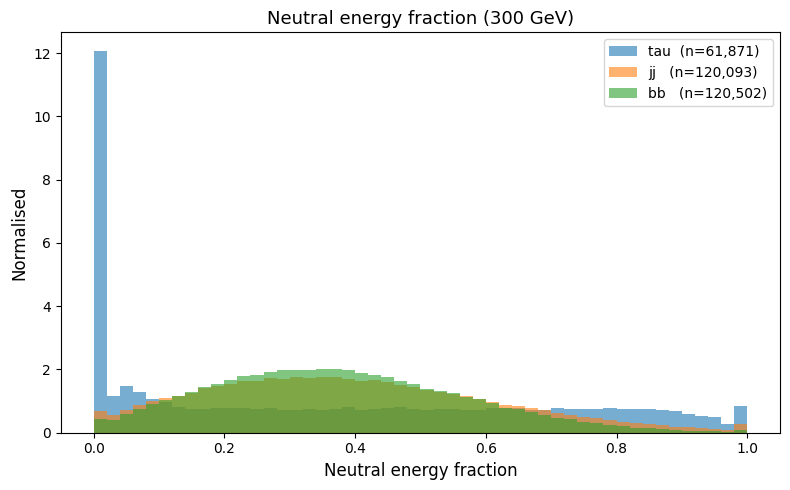

Plotting kinematics:  64%|██████▍   | 9/14 [00:17<00:09,  1.92s/it]

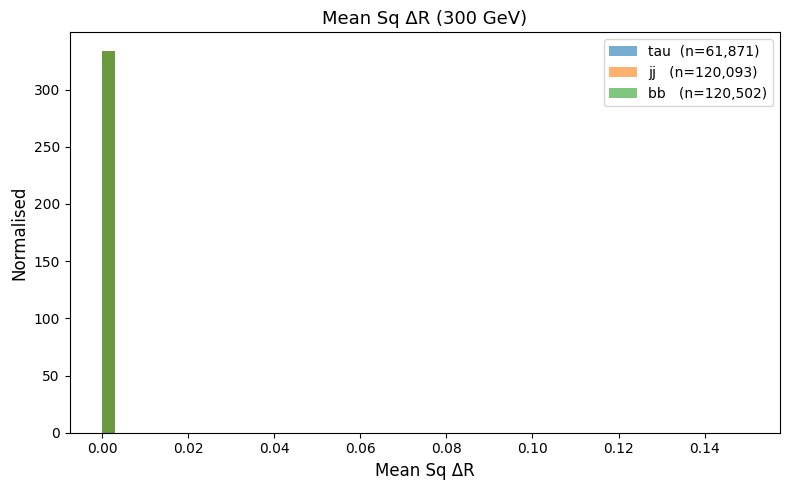

Plotting kinematics:  71%|███████▏  | 10/14 [00:19<00:07,  1.92s/it]

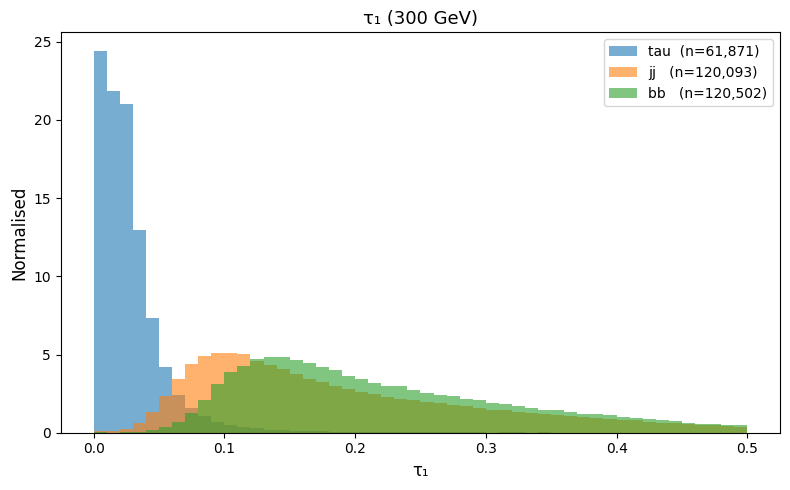

Plotting kinematics:  79%|███████▊  | 11/14 [00:20<00:05,  1.85s/it]

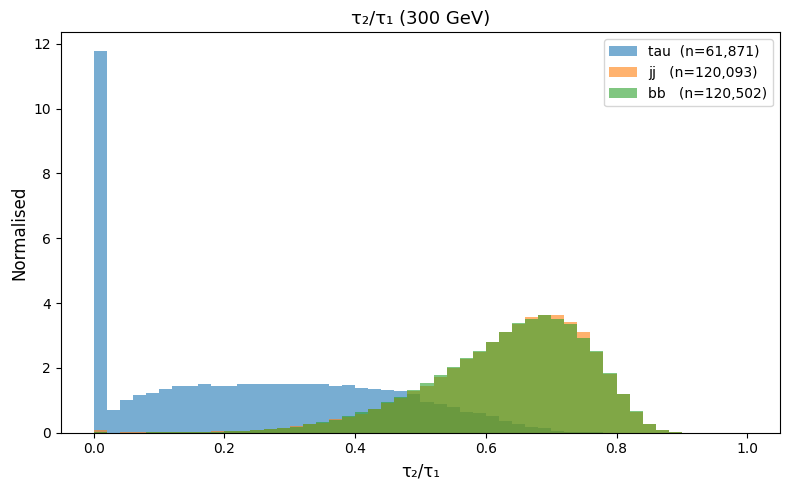

Plotting kinematics:  86%|████████▌ | 12/14 [00:22<00:03,  1.83s/it]

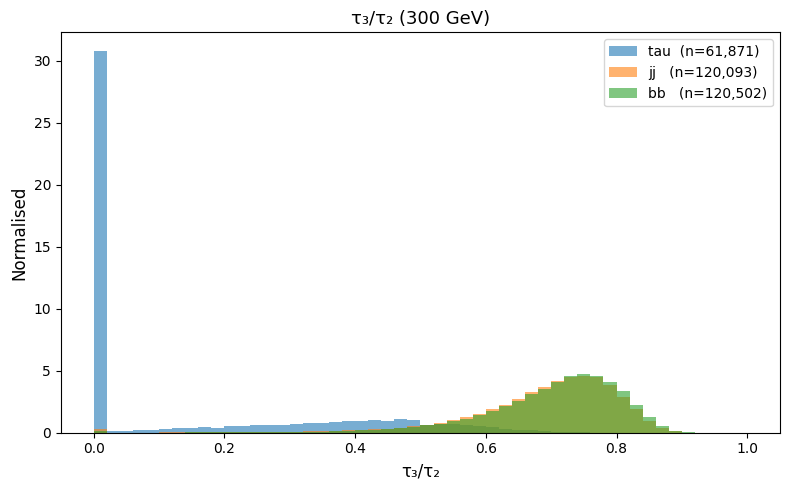

Plotting kinematics:  93%|█████████▎| 13/14 [00:24<00:01,  1.79s/it]

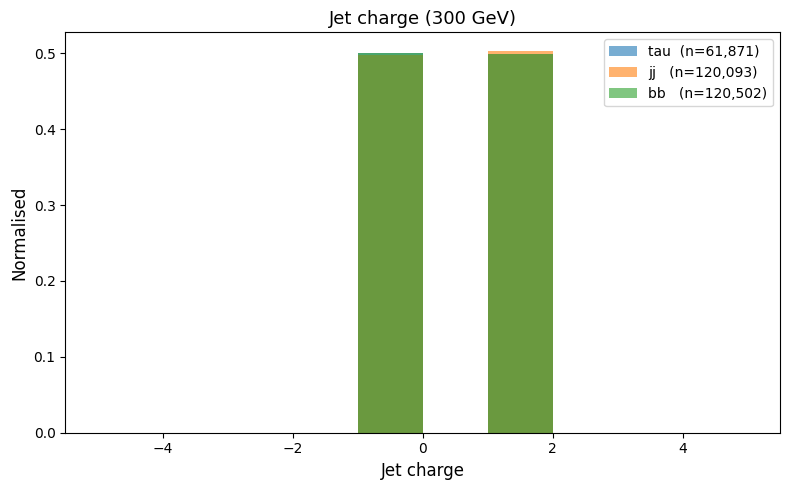

Plotting kinematics: 100%|██████████| 14/14 [00:25<00:00,  1.81s/it]



Signal vs background comparison plots...


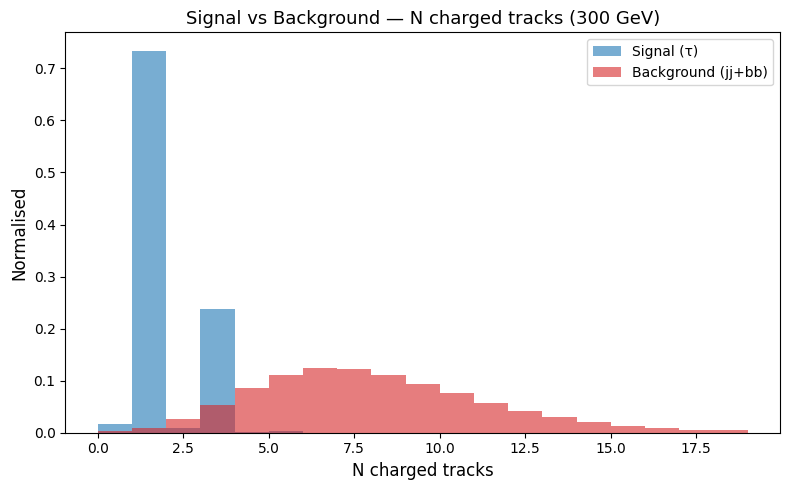

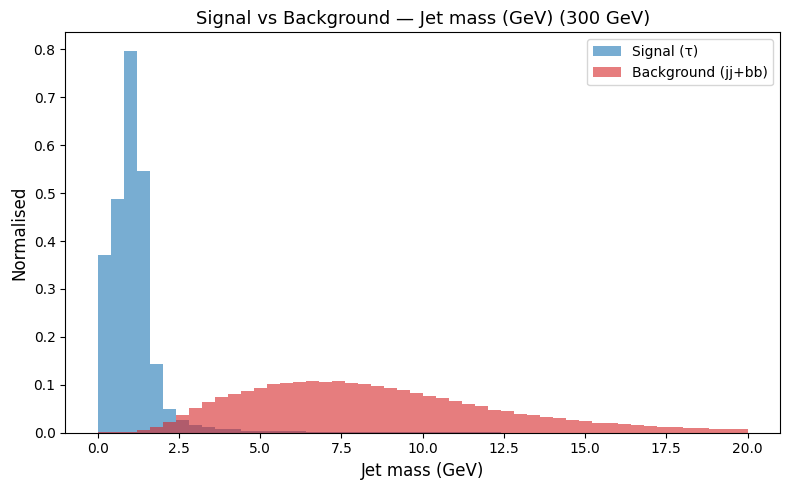

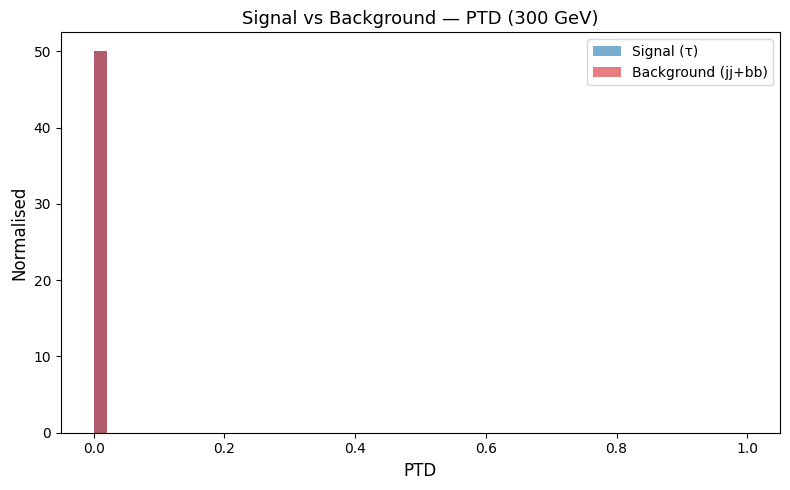

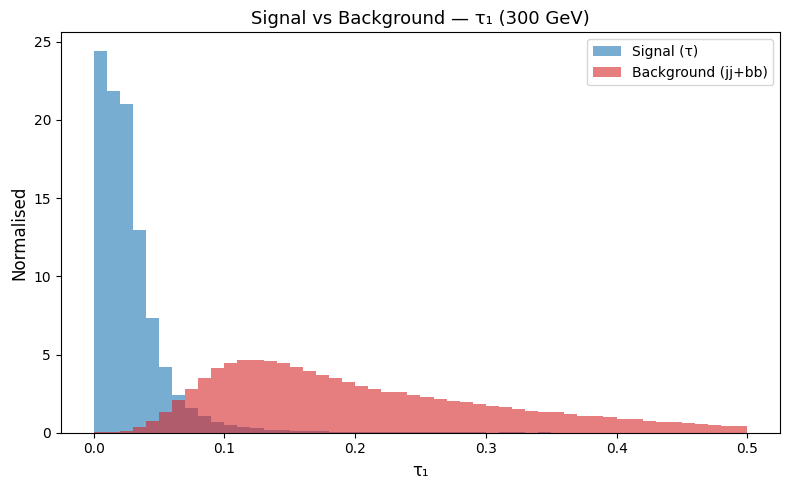

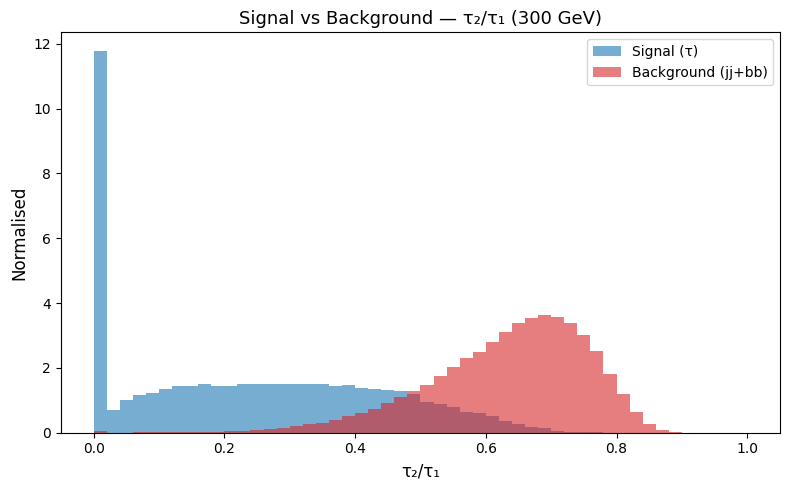

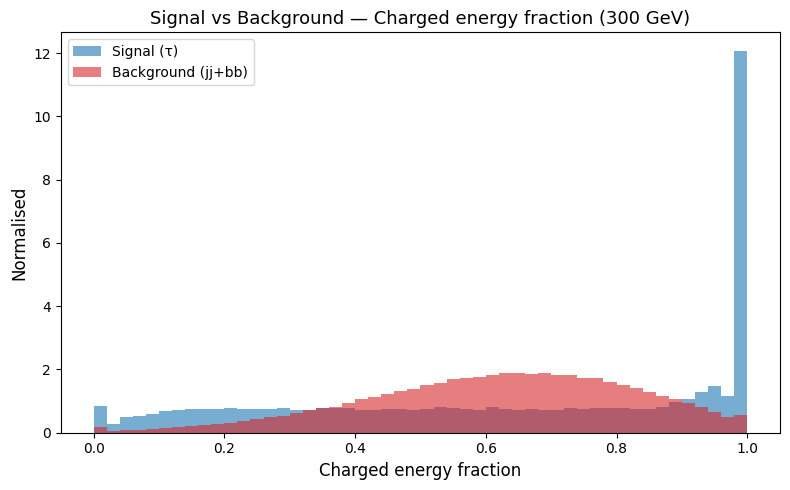

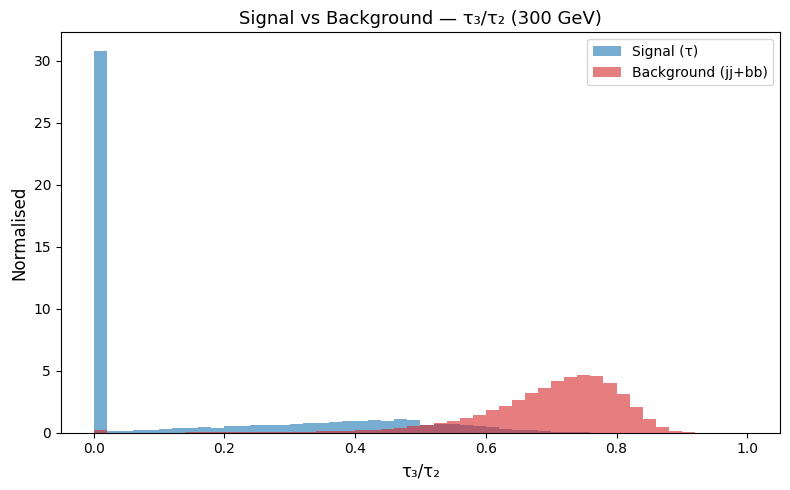

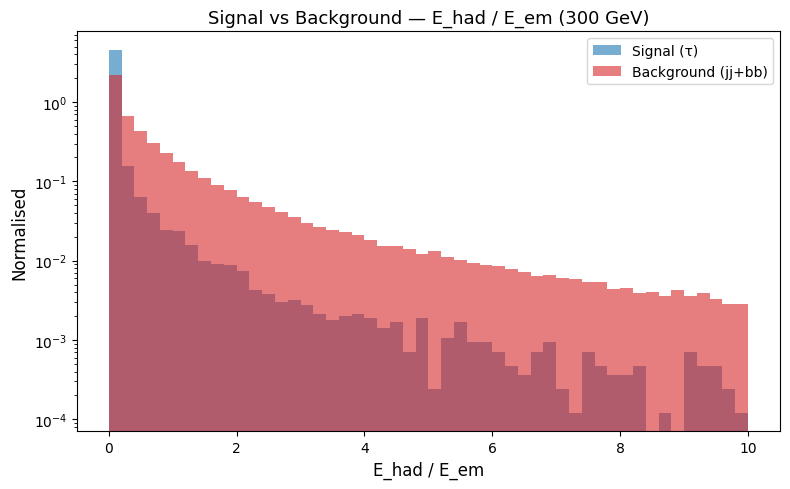

In [69]:
# ══════════════════════════════════════════════════════════════════
# SECTION 4 — Full kinematics with pT window
# ══════════════════════════════════════════════════════════════════
rsep()
rlog(f"SECTION 4 — Full kinematics (pT {PT_MIN}–{PT_MAX} GeV)")
rsep()

def load_jets(fname):
    t0   = time.time()
    tree = uproot.open(ROOT_PATH / fname)["Delphes;1"]
    branches = [
        "Jet/Jet.PT", "Jet/Jet.Eta", "Jet/Jet.Phi", "Jet/Jet.Mass",
        "Jet/Jet.NCharged", "Jet/Jet.NNeutrals",
        "Jet/Jet.EhadOverEem", "Jet/Jet.PTD",
        "Jet/Jet.ChargedEnergyFraction", "Jet/Jet.NeutralEnergyFraction",
        "Jet/Jet.MeanSqDeltaR", "Jet/Jet.Charge",
        "Jet/Jet.BTag", "Jet/Jet.TauTag", "Jet/Jet.Tau[5]",
    ]
    data = {b: tree[b].array(library="ak") for b in branches}
    pt   = np.asarray(np.concatenate(data["Jet/Jet.PT"]))
    mask = (pt >= PT_MIN) & (pt <= PT_MAX)
    tau_arr = np.asarray(np.concatenate(data["Jet/Jet.Tau[5]"]))

    result = {
        "pt":    pt[mask],
        "eta":   np.asarray(np.concatenate(data["Jet/Jet.Eta"]))[mask],
        "mass":  np.asarray(np.concatenate(data["Jet/Jet.Mass"]))[mask],
        "nch":   np.asarray(np.concatenate(data["Jet/Jet.NCharged"]))[mask],
        "nneu":  np.asarray(np.concatenate(data["Jet/Jet.NNeutrals"]))[mask],
        "ehad":  np.asarray(np.concatenate(data["Jet/Jet.EhadOverEem"]))[mask],
        "ptd":   np.asarray(np.concatenate(data["Jet/Jet.PTD"]))[mask],
        "chf":   np.asarray(np.concatenate(data["Jet/Jet.ChargedEnergyFraction"]))[mask],
        "nef":   np.asarray(np.concatenate(data["Jet/Jet.NeutralEnergyFraction"]))[mask],
        "msdr":  np.asarray(np.concatenate(data["Jet/Jet.MeanSqDeltaR"]))[mask],
        "charge":np.asarray(np.concatenate(data["Jet/Jet.Charge"]))[mask],
        "btag":  np.asarray(np.concatenate(data["Jet/Jet.BTag"]))[mask],
        "tautag":np.asarray(np.concatenate(data["Jet/Jet.TauTag"]))[mask],
        "tau1":  tau_arr[:, 0][mask],
        "tau2":  tau_arr[:, 1][mask],
        "tau3":  tau_arr[:, 2][mask],
    }
    result["tau21"] = np.where(result["tau1"] > 0,
                               result["tau2"] / result["tau1"], 0)
    result["tau32"] = np.where(result["tau2"] > 0,
                               result["tau3"] / result["tau2"], 0)
    rlog(f"  Loaded {fname} — {mask.sum():,} jets  ({time.time()-t0:.1f}s)")
    return result

rlog("\nLoading jets...")
tau = load_jets(FILES["tau"])
jj  = load_jets(FILES["jj"])
bb  = load_jets(FILES["bb"])

# substructure sanity check
rlog("\nSubstructure branch check:")
for name, d in [("tau", tau), ("jj", jj), ("bb", bb)]:
    rlog(f"  {name:>4s} : PTD nonzero={np.count_nonzero(d['ptd']):,}  "
         f"MSDR nonzero={np.count_nonzero(d['msdr']):,}  "
         f"Tau1 nonzero={np.count_nonzero(d['tau1']):,}  "
         f"Tau1 mean={d['tau1'].mean():.4f}")

# ── plot helper ───────────────────────────────────────────────────
def plot_var(key_tau, key_jj, key_bb, xlabel, title, fname,
             bins=50, xrange=None, log_y=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    kwargs = dict(bins=bins, range=xrange, density=True, alpha=0.6)
    ax.hist(key_tau, **kwargs, color=COLORS["tau"], label=f"tau  (n={len(key_tau):,})")
    ax.hist(key_jj,  **kwargs, color=COLORS["jj"],  label=f"jj   (n={len(key_jj):,})")
    ax.hist(key_bb,  **kwargs, color=COLORS["bb"],  label=f"bb   (n={len(key_bb):,})")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Normalised", fontsize=12)
    ax.set_title(f"{title} ({ENERGY_TAG})", fontsize=13)
    ax.legend()
    if log_y:
        ax.set_yscale("log")
    plt.tight_layout()
    plt.savefig(PLOT_PATH / fname, dpi=150)
    plt.show()
    plt.close()

# ── all kinematic plots ───────────────────────────────────────────
plots = [
    ("pt",    "Jet pT (GeV)",            "01_pt.png",       50,           (PT_MIN, PT_MAX), False),
    ("eta",   "Jet η",                   "02_eta.png",      50,           (-3, 3),          False),
    ("mass",  "Jet mass (GeV)",          "03_mass.png",     50,           (0, 20),          False),
    ("nch",   "N charged tracks",        "04_ncharged.png", range(0,20),  (0, 20),          False),
    ("nneu",  "N neutral particles",     "05_nneutrals.png",range(0,20),  (0, 20),          False),
    ("ehad",  "E_had / E_em",            "06_ehad.png",     50,           (0, 10),          True),
    ("ptd",   "PTD",                     "07_ptd.png",      50,           (0, 1),           False),
    ("chf",   "Charged energy fraction", "08_chf.png",      50,           (0, 1),           False),
    ("nef",   "Neutral energy fraction", "09_nef.png",      50,           (0, 1),           False),
    ("msdr",  "Mean Sq ΔR",              "10_msdr.png",     50,           (0, 0.15),        False),
    ("tau1",  "τ₁",                      "11_tau1.png",     50,           (0, 0.5),         False),
    ("tau21", "τ₂/τ₁",                   "12_tau21.png",    50,           (0, 1),           False),
    ("tau32", "τ₃/τ₂",                   "13_tau32.png",    50,           (0, 1),           False),
    ("charge","Jet charge",              "14_charge.png",   range(-5,6),  (-5, 5),          False),
]

for key, xlabel, fname, bins, xrange, logy in tqdm(plots, desc="Plotting kinematics"):
    plot_var(tau[key], jj[key], bb[key], xlabel, xlabel, fname,
             bins=bins, xrange=xrange, log_y=logy)

# ── signal vs background overlay ─────────────────────────────────
rlog("\nSignal vs background comparison plots...")
bkg = {k: np.concatenate([jj[k], bb[k]]) for k in tau.keys()}

sig_bkg_plots = [
    ("nch",  "N charged tracks",        "sb_ncharged.png", range(0,20), (0,20),   False),
    ("mass", "Jet mass (GeV)",          "sb_mass.png",     50,          (0,20),   False),
    ("ptd",  "PTD",                     "sb_ptd.png",      50,          (0,1),    False),
    ("tau1", "τ₁",                      "sb_tau1.png",     50,          (0,0.5),  False),
    ("tau21","τ₂/τ₁",                   "sb_tau21.png",    50,          (0,1),    False),
    ("chf",  "Charged energy fraction", "sb_chf.png",      50,          (0,1),    False),
    ("tau32","τ₃/τ₂",                   "sb_tau32.png",    50,          (0,1),    False),
    ("ehad", "E_had / E_em",            "sb_ehad.png",     50,          (0,10),   True),
]

for key, xlabel, fname, bins, xrange, logy in sig_bkg_plots:
    fig, ax = plt.subplots(figsize=(8, 5))
    kwargs = dict(bins=bins, range=xrange, density=True, alpha=0.6)
    ax.hist(tau[key], **kwargs, color="tab:blue", label="Signal (τ)")
    ax.hist(bkg[key], **kwargs, color="tab:red",  label="Background (jj+bb)")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Normalised", fontsize=12)
    ax.set_title(f"Signal vs Background — {xlabel} ({ENERGY_TAG})", fontsize=13)
    if logy: ax.set_yscale("log")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOT_PATH / fname, dpi=150)
    plt.show()
    plt.close()


Section 5 — N-subjettiness 2D scatter


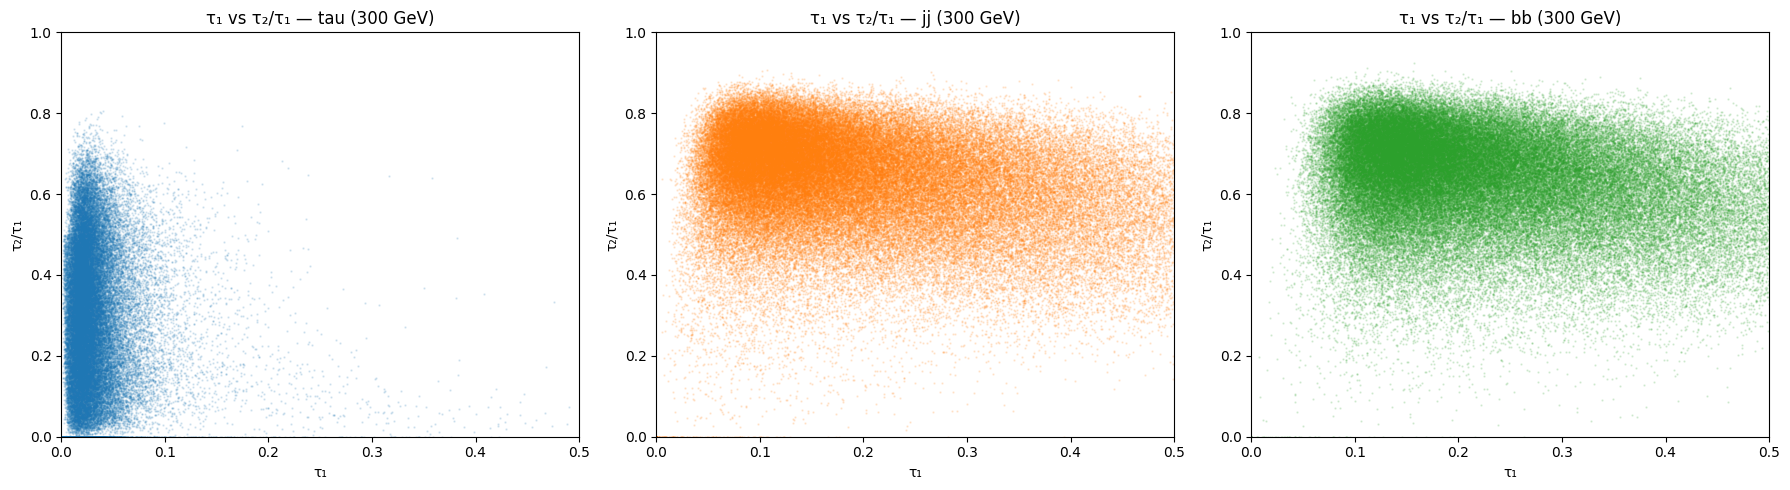

C:\Users\User\AppData\Local\Temp\ipykernel_17868\754762798.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_17868\754762798.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(PLOT_PATH / "16b_tau1_vs_tau21_overlay.png", dpi=150)
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


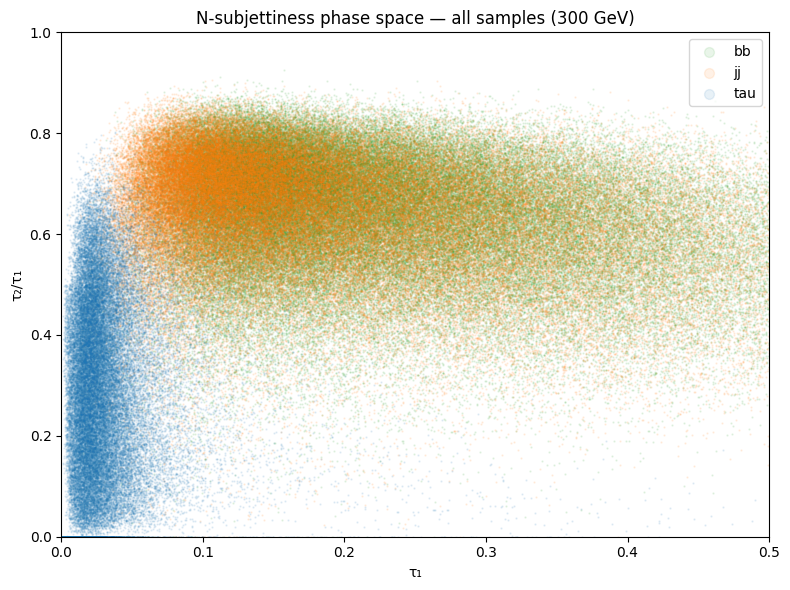

In [70]:
# ══════════════════════════════════════════════════════════════════
# SECTION 5 — N-subjettiness 2D scatter (tau1 vs tau21)
# Best single plot to visualise signal/background separation
# in substructure space.
# ══════════════════════════════════════════════════════════════════
rlog("\nSection 5 — N-subjettiness 2D scatter")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, d) in zip(axes, [("tau", tau), ("jj", jj), ("bb", bb)]):
    ax.scatter(d["tau1"], d["tau21"], s=0.5, alpha=0.15,
               color=COLORS[name], rasterized=True)
    ax.set_xlabel("τ₁")
    ax.set_ylabel("τ₂/τ₁")
    ax.set_title(f"τ₁ vs τ₂/τ₁ — {name} ({ENERGY_TAG})")
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PLOT_PATH / "16_tau1_vs_tau21_scatter.png", dpi=150)
plt.show()

# overlay all three
fig, ax = plt.subplots(figsize=(8, 6))
for name, d in [("bb", bb), ("jj", jj), ("tau", tau)]:
    ax.scatter(d["tau1"], d["tau21"], s=0.5, alpha=0.1,
               color=COLORS[name], label=name, rasterized=True)
ax.set_xlabel("τ₁")
ax.set_ylabel("τ₂/τ₁")
ax.set_title(f"N-subjettiness phase space — all samples ({ENERGY_TAG})")
ax.legend(markerscale=10)
ax.set_xlim(0, 0.5); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(PLOT_PATH / "16b_tau1_vs_tau21_overlay.png", dpi=150)
plt.show()


Section 6 — tau prong decomposition
  tau 1-prong  (NCharged=1) : 45,329  (73.3%)
  tau 3-prong  (NCharged=3) : 14,720  (23.8%)
  other                     : 1,822  (2.9%)


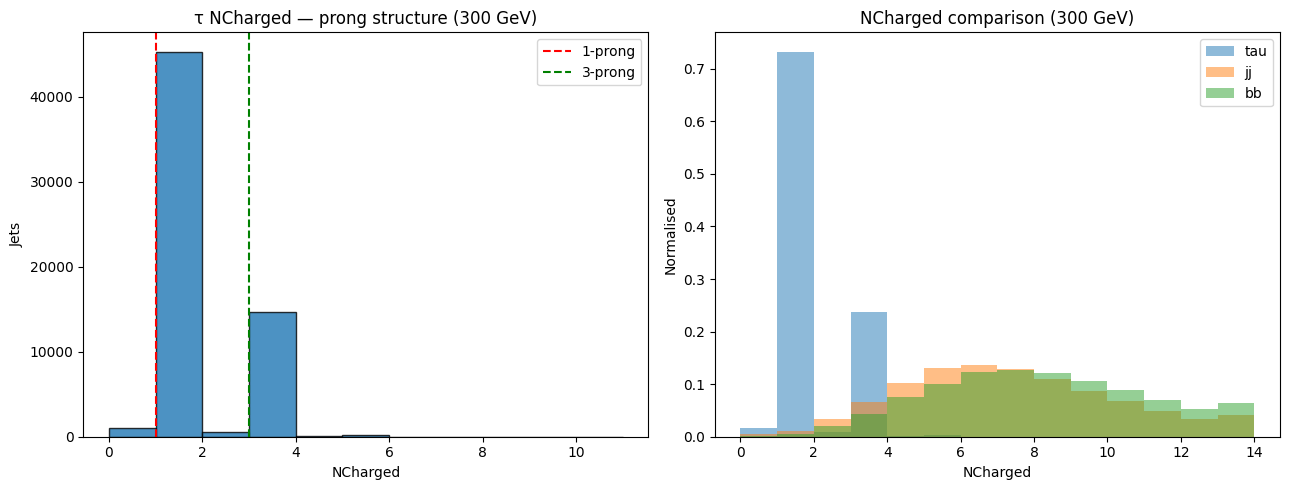

In [71]:
# ══════════════════════════════════════════════════════════════════
# SECTION 6 — 1-prong / 3-prong decomposition for tau
# Important physics check — hadronic tau decays are either
# 1-prong (1 charged track) or 3-prong (3 charged tracks)
# ══════════════════════════════════════════════════════════════════
rlog("\nSection 6 — tau prong decomposition")
nch_tau = tau["nch"]
one_prong   = (nch_tau == 1).sum()
three_prong = (nch_tau == 3).sum()
other       = len(nch_tau) - one_prong - three_prong

rlog(f"  tau 1-prong  (NCharged=1) : {one_prong:,}  "
     f"({100*one_prong/len(nch_tau):.1f}%)")
rlog(f"  tau 3-prong  (NCharged=3) : {three_prong:,}  "
     f"({100*three_prong/len(nch_tau):.1f}%)")
rlog(f"  other                     : {other:,}  "
     f"({100*other/len(nch_tau):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# NCharged for tau only, zoomed in
axes[0].hist(nch_tau, bins=range(0, 12), edgecolor="black",
             color=COLORS["tau"], alpha=0.8)
axes[0].axvline(1, color="red",   ls="--", label="1-prong")
axes[0].axvline(3, color="green", ls="--", label="3-prong")
axes[0].set_xlabel("NCharged")
axes[0].set_ylabel("Jets")
axes[0].set_title(f"τ NCharged — prong structure ({ENERGY_TAG})")
axes[0].legend()

# compare tau/jj/bb NCharged side by side
for name, d in [("tau", tau), ("jj", jj), ("bb", bb)]:
    axes[1].hist(d["nch"], bins=range(0, 15), alpha=0.5,
                 color=COLORS[name], label=name, density=True)
axes[1].set_xlabel("NCharged")
axes[1].set_ylabel("Normalised")
axes[1].set_title(f"NCharged comparison ({ENERGY_TAG})")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_PATH / "17_prong_structure.png", dpi=150)
plt.show()


Section 7 — Separation power (Wasserstein distance)

         Variable    Wasserstein dist
  ------------------------------------
               τ₁              0.1966
            τ₂/τ₁              0.4267
            τ₃/τ₂              0.5861
         NCharged              0.2049
             mass              0.1996
              CHF              0.1229
              NEF              0.1229
      EhadOverEem              0.2860
               pT              0.0628


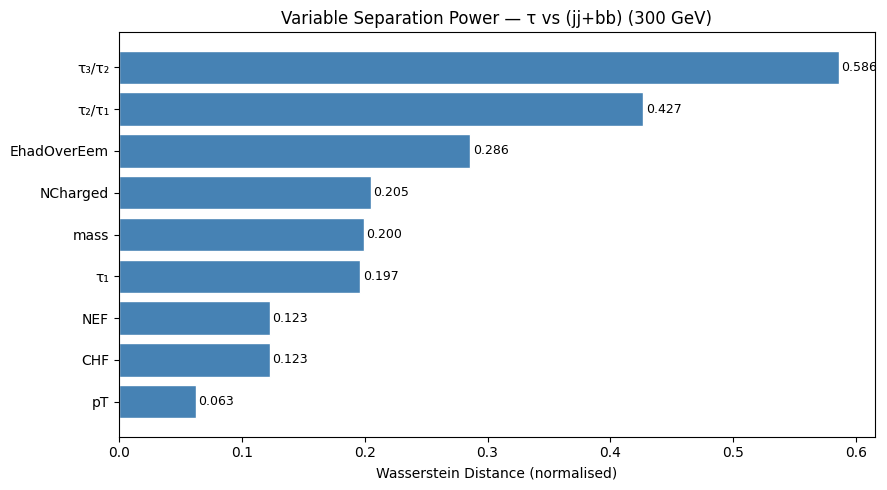

In [72]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — Separation power (Wasserstein distance)
# Quantifies how different each variable's distribution is
# between signal and background. Higher = better discriminant.
# ══════════════════════════════════════════════════════════════════
rlog("\nSection 7 — Separation power (Wasserstein distance)")

sep_vars = {
    "τ₁"    : ("tau1",  tau["tau1"],  bkg["tau1"]),
    "τ₂/τ₁" : ("tau21", tau["tau21"], bkg["tau21"]),
    "τ₃/τ₂" : ("tau32", tau["tau32"], bkg["tau32"]),
    "NCharged":("nch",   tau["nch"],   bkg["nch"]),
    "mass"  : ("mass",  tau["mass"],  bkg["mass"]),
    "CHF"   : ("chf",   tau["chf"],   bkg["chf"]),
    "NEF"   : ("nef",   tau["nef"],   bkg["nef"]),
    "EhadOverEem":("ehad",tau["ehad"],bkg["ehad"]),
    "pT"    : ("pt",    tau["pt"],    bkg["pt"]),
}

sep_scores = {}
rlog(f"\n  {'Variable':>15s}  {'Wasserstein dist':>18s}")
rlog("  " + "-"*36)
for label, (key, sig, bkg_arr) in sep_vars.items():
    # normalise both to [0,1] range before computing distance
    combined = np.concatenate([sig, bkg_arr])
    lo, hi   = combined.min(), combined.max()
    if hi > lo:
        sig_n  = (sig - lo) / (hi - lo)
        bkg_n  = (bkg_arr - lo) / (hi - lo)
        wd     = wasserstein_distance(sig_n, bkg_n)
    else:
        wd = 0.0
    sep_scores[label] = wd
    rlog(f"  {label:>15s}  {wd:>18.4f}")

# bar chart of separation power
fig, ax = plt.subplots(figsize=(9, 5))
keys_sorted = sorted(sep_scores, key=sep_scores.get, reverse=True)
vals_sorted = [sep_scores[k] for k in keys_sorted]
bars = ax.barh(keys_sorted, vals_sorted, color="steelblue", edgecolor="white")
ax.set_xlabel("Wasserstein Distance (normalised)")
ax.set_title(f"Variable Separation Power — τ vs (jj+bb) ({ENERGY_TAG})")
ax.invert_yaxis()
for bar, val in zip(bars, vals_sorted):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_PATH / "18_separation_power.png", dpi=150)
plt.show()


Section 8 — Tagger efficiency (with pT cut)

  Sample    TauTag %      BTag %      N jets
  ------------------------------------------
     tau       39.8%        1.3%      61,871
      jj        0.2%        6.7%     120,093
      bb        1.5%       57.8%     120,502


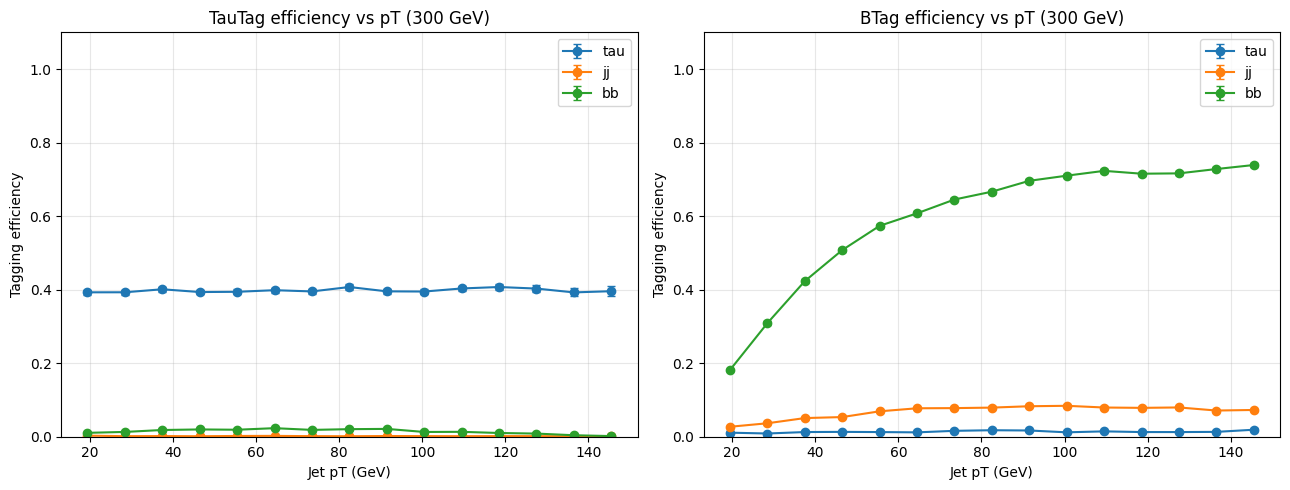

In [73]:
# ══════════════════════════════════════════════════════════════════
# SECTION 8 — BTag and TauTag efficiency table (with pT cut)
# ══════════════════════════════════════════════════════════════════
rlog("\nSection 8 — Tagger efficiency (with pT cut)")
rlog(f"\n  {'Sample':>6s}  {'TauTag %':>10s}  {'BTag %':>10s}  {'N jets':>10s}")
rlog("  " + "-"*42)
for name, d in [("tau", tau), ("jj", jj), ("bb", bb)]:
    rlog(f"  {name:>6s}  "
         f"{d['tautag'].mean()*100:>9.1f}%  "
         f"{d['btag'].mean()*100:>9.1f}%  "
         f"{len(d['pt']):>10,}")

# ── TauTag efficiency vs pT ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pt_bins = np.linspace(PT_MIN, PT_MAX, 16)
bc      = 0.5 * (pt_bins[:-1] + pt_bins[1:])

for ax, tag_key, title in zip(axes,
    ["tautag", "btag"],
    ["TauTag efficiency vs pT", "BTag efficiency vs pT"]
):
    for name, d in [("tau", tau), ("jj", jj), ("bb", bb)]:
        eff, err = [], []
        for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
            sel = (d["pt"] >= lo) & (d["pt"] < hi)
            n   = sel.sum()
            if n == 0:
                eff.append(np.nan); err.append(np.nan)
                continue
            k = d[tag_key][sel].sum()
            e = k / n
            eff.append(e)
            err.append(np.sqrt(e*(1-e)/n))
        ax.errorbar(bc, eff, yerr=err, fmt="o-",
                    color=COLORS[name], capsize=3, label=name)
    ax.set_xlabel("Jet pT (GeV)")
    ax.set_ylabel("Tagging efficiency")
    ax.set_title(f"{title} ({ENERGY_TAG})")
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_PATH / "19_tagger_eff_vs_pt.png", dpi=150)
plt.show()


Section 9 — Correlation matrices


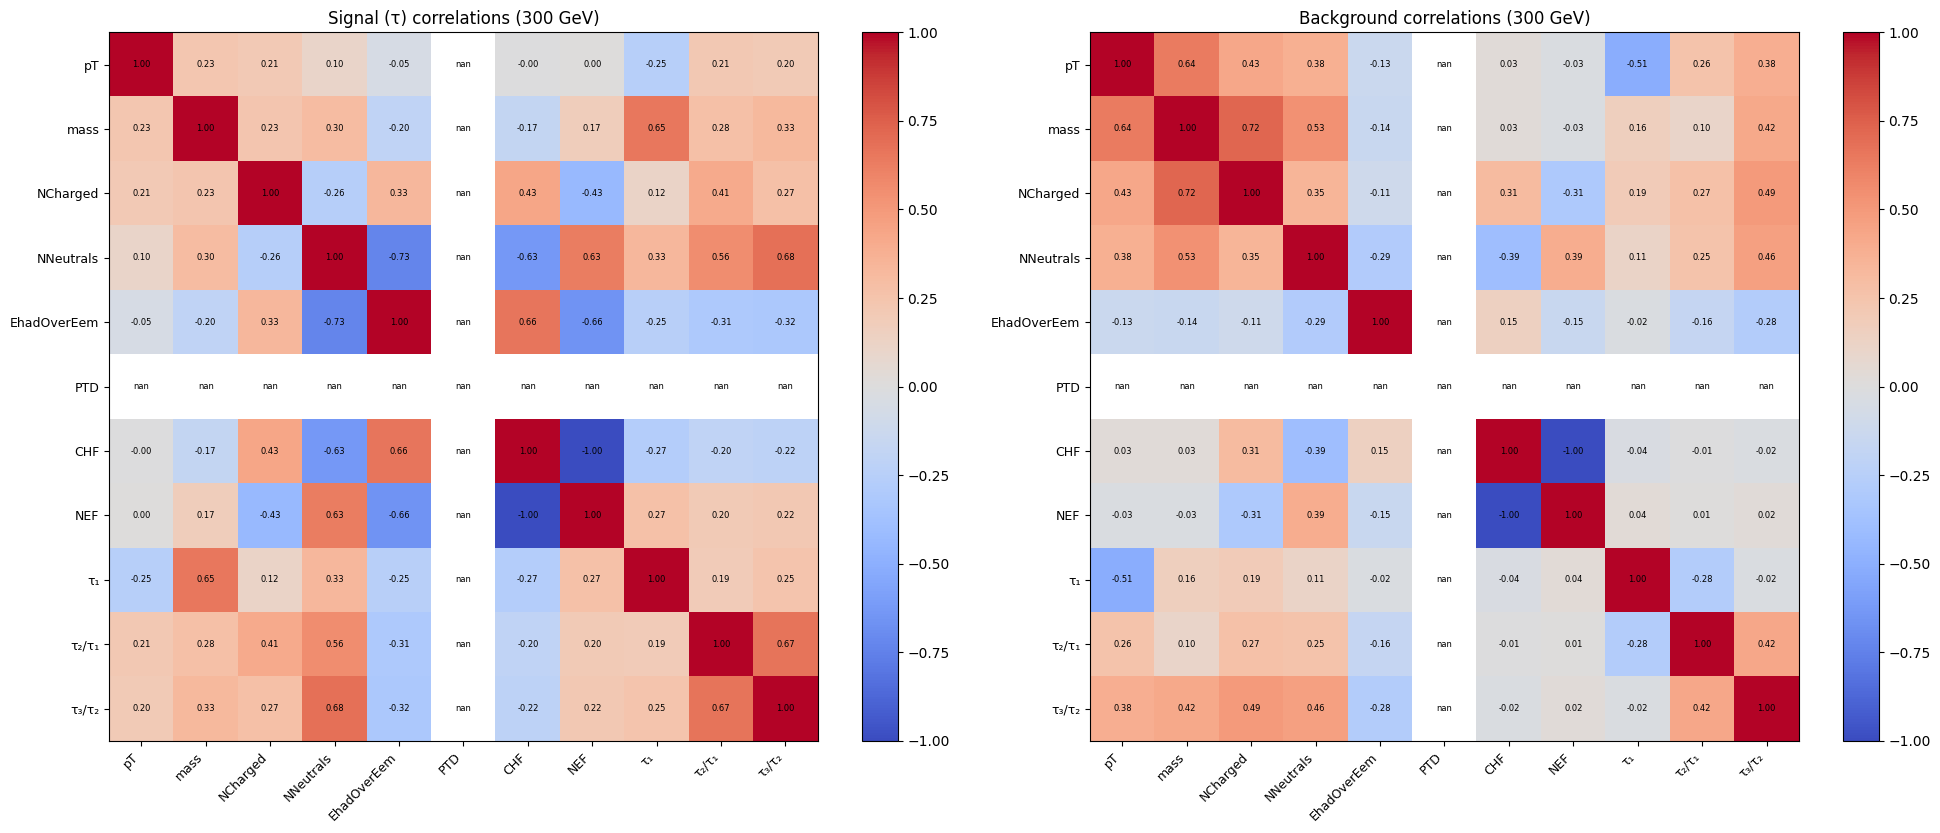

In [74]:
# ══════════════════════════════════════════════════════════════════
# SECTION 9 — Correlation matrices (unchanged + improved)
# ══════════════════════════════════════════════════════════════════
rlog("\nSection 9 — Correlation matrices")

feature_names = ["pT", "mass", "NCharged", "NNeutrals", "EhadOverEem",
                 "PTD", "CHF", "NEF", "τ₁", "τ₂/τ₁", "τ₃/τ₂"]

def make_df(d):
    return pd.DataFrame({
        "pT":d["pt"],"mass":d["mass"],"NCharged":d["nch"],"NNeutrals":d["nneu"],
        "EhadOverEem":d["ehad"],"PTD":d["ptd"],"CHF":d["chf"],"NEF":d["nef"],
        "τ₁":d["tau1"],"τ₂/τ₁":d["tau21"],"τ₃/τ₂":d["tau32"],
    })

df_tau = make_df(tau)
df_bkg = make_df(bkg)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, df, title in [(axes[0], df_tau, f"Signal (τ) correlations ({ENERGY_TAG})"),
                       (axes[1], df_bkg, f"Background correlations ({ENERGY_TAG})")]:
    corr = df.corr()
    im   = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(feature_names)))
    ax.set_yticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(feature_names, fontsize=9)
    ax.set_title(title, fontsize=12)
    for i in range(len(feature_names)):
        for j in range(len(feature_names)):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}",
                    ha="center", va="center", fontsize=6)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(PLOT_PATH / "15_correlations.png", dpi=150)
plt.show()

In [75]:
# ══════════════════════════════════════════════════════════════════
# SECTION 10 — Summary statistics table
# ══════════════════════════════════════════════════════════════════
rsep()
rlog("SECTION 10 — Summary statistics")
rsep()

stat_keys = [
    ("pt",    "pT (GeV)"),
    ("mass",  "Mass (GeV)"),
    ("nch",   "NCharged"),
    ("tau1",  "τ₁"),
    ("tau21", "τ₂/τ₁"),
    ("tau32", "τ₃/τ₂"),
    ("chf",   "CHF"),
    ("nef",   "NEF"),
    ("ehad",  "EhadOverEem"),
]

rlog(f"\n  {'Variable':>14s}  "
     f"{'tau mean':>10s}  {'tau std':>9s}  "
     f"{'jj mean':>9s}  {'jj std':>8s}  "
     f"{'bb mean':>9s}  {'bb std':>8s}")
rlog("  " + "-"*80)

for key, label in stat_keys:
    rlog(f"  {label:>14s}  "
         f"{tau[key].mean():>10.4f}  {tau[key].std():>9.4f}  "
         f"{jj[key].mean():>9.4f}  {jj[key].std():>8.4f}  "
         f"{bb[key].mean():>9.4f}  {bb[key].std():>8.4f}")

# jet counts final
rsep()
rlog("FINAL JET COUNTS (after pT window)")
rsep()
total = len(tau["pt"]) + len(jj["pt"]) + len(bb["pt"])
rlog(f"  tau : {len(tau['pt']):>7,}  (signal,  label=1)")
rlog(f"  jj  : {len(jj['pt']):>7,}  (background, sample_id=1)")
rlog(f"  bb  : {len(bb['pt']):>7,}  (background, sample_id=2)")
rlog(f"  total : {total:>7,}")
rlog(f"  sig:bkg ratio = 1 : {(len(jj['pt'])+len(bb['pt']))/len(tau['pt']):.2f}")
rlog(f"\npT window used : {PT_MIN}–{PT_MAX} GeV")
rlog(f"Cone size      : dR < 0.4")
rlog(f"Energy         : {ENERGY_TAG}")

# ══════════════════════════════════════════════════════════════════
# SAVE TEXT REPORT
# ══════════════════════════════════════════════════════════════════
report_path = PLOT_PATH / f"kinematics_report_{ENERGY_TAG.replace(' ','')}.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

rlog(f"\nAll plots saved to  : {PLOT_PATH}")
rlog(f"Text report saved to: {report_path}")

SECTION 10 — Summary statistics

        Variable    tau mean    tau std    jj mean    jj std    bb mean    bb std
  --------------------------------------------------------------------------------
        pT (GeV)     72.5494    34.4086    81.5663   40.3474    78.3741   38.6341
      Mass (GeV)      1.1180     1.1582     8.6426    4.5190     8.9569    4.3150
        NCharged      1.4820     0.8928     7.1408    3.3023     8.1162    3.4657
              τ₁      0.0275     0.0310     0.2008    0.1242     0.2306    0.1181
           τ₂/τ₁      0.2382     0.1945     0.6326    0.1236     0.6333    0.1207
           τ₃/τ₂      0.1486     0.2104     0.6892    0.1211     0.7011    0.1109
             CHF      0.6423     0.3214     0.6066    0.2155     0.6245    0.1896
             NEF      0.3577     0.3214     0.3934    0.2155     0.3755    0.1896
     EhadOverEem    320.1397   466.3881    45.3215  204.4852    23.4257  147.4583
FINAL JET COUNTS (after pT window)
  tau :  61,871  (signal,  la